In [1]:
import pandas as pd

import pickle

from tqdm.notebook import tqdm

import os

from IPython.display import display, Markdown

import json

from pythonjsonlogger.json import JsonFormatter

from adr import adr

from typing import Literal, Dict, List, Tuple

import logging
import sys
import numpy as np
from itertools import cycle, islice

from sentence_transformers import SentenceTransformer

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from catboost import CatBoostClassifier

import seaborn as sns # Optional: for a visual heatmap
import matplotlib.pyplot as plt # Optional: for plotting

from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from langchain_core.embeddings import Embeddings
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import OpenAIEmbeddings

from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import matthews_corrcoef

# from umap import UMAP

import os
from dotenv import load_dotenv

from adr_classification import ZimmermannEnum, KruchtenEnum, QualityAttributesEnum

import utils

In [2]:
print(load_dotenv())

True


In [3]:
# Define the embeddings model to use with the text of the ADRs

# DEFAULT_EMBEDDINGS = os.environ["OPENAI_EMBEDDINGS_MODEL"]
# embeddings_model = OpenAIEmbeddings( # Dimensions is 1536
#     model=os.environ["OPENAI_EMBEDDINGS_MODEL"], # text-embedding-3-small
#     api_key=os.environ["OPENAI_API_KEY"]
#     # With the `text-embedding-3` class of models, you can specify the size of the embeddings you want returned.
#     # dimensions=1024
# )

DEFAULT_EMBEDDINGS = "all-MiniLM-L6-v2"
embeddings_model = HuggingFaceEmbeddings(model=DEFAULT_EMBEDDINGS) # Dimensions is 384

# vector = embeddings_model.embed_query(text="This is a test!")
# print(len(vector))
# vector

In [4]:
# Ground truth datasets for each decision categorization framework

# KRUCHTEN_GROUND_TRUTH = './sample/kruchten_gt_processed1.csv'
KRUCHTEN_GROUND_TRUTH = './sample/kruchten_gt_processed1_checked1.csv'

# QAS_GROUND_TRUTH = './sample/qas_gt_processed1.csv'
QAS_GROUND_TRUTH = './sample/qas_gt_processed1_checked1.csv'

ZIMMERMANN_GROUND_TRUTH = './sample/zimmermann_gt_processed1.csv'

---

### Krutchen's Ontology for Design Decisions

In [5]:
labels = [str(member.value) for member in KruchtenEnum]
print(len(labels), labels)

4 ['Existence (ontocrisis)', 'Ban/Non-Existence (anticrisis)', 'Property (diacrisis)', 'Executive (pericrisis)']


In [6]:
# Load the ground truth dataset
relative_path = os.path.join('..', KRUCHTEN_GROUND_TRUTH)
df_gt = pd.read_csv(relative_path, sep=';').dropna(subset=['text', 'human', 'ADR'])
print(df_gt.shape)
print(len(df_gt['human'].unique()), df_gt['human'].unique())
print(len(df_gt['primary_category'].unique()), df_gt['primary_category'].unique())

df_gt.head()

(200, 10)
4 ['Existence (ontocrisis)' 'Executive (pericrisis)' 'Property (diacrisis)'
 'Ban/Non-Existence (anticrisis)']
4 ['Existence (ontocrisis)' 'Property (diacrisis)' 'Executive (pericrisis)'
 'Ban/Non-Existence (anticrisis)']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,human_old,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Existence (ontocrisis),The ADR describes the implementation of a conn...,"0,85",Existence (ontocrisis),Existence (ontocrisis),1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Existence (ontocrisis),The ADR describes a decision to implement prov...,"0,85",Existence (ontocrisis),Existence (ontocrisis),1.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Property (diacrisis),The ADR primarily discusses versioning strateg...,"0,80",Executive (pericrisis),Executive (pericrisis),0.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Existence (ontocrisis),The ADR primarily discusses decisions related ...,"0,85",Executive (pericrisis),Existence (ontocrisis),1.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Executive (pericrisis),The ADR discusses a process and policy change ...,"0,90",Executive (pericrisis),Executive (pericrisis),1.0,# Cutting release branch does not create a set...


In [7]:
# Convert the column to a list of strings
sentences = df_gt['raw_text'].tolist()

# Generate embeddings (numpy array)

file = "./sample/raw_text_"+DEFAULT_EMBEDDINGS+".csv"
relative_path = os.path.join('..', file)
if not os.path.isfile(relative_path):
    print("Computing and saving embeddings ...", relative_path)
    embeddings = embeddings_model.embed_documents(sentences)
    embeddings_df = pd.DataFrame(embeddings)
    embeddings_df.to_csv(relative_path, index=False)
else:
    print("Loading embeddings ...", relative_path)
    embeddings_df = pd.read_csv(relative_path)
    embeddings = embeddings_df.values
print("Embeddings dimensions:", embeddings_df.shape)

# Encoding target
le = LabelEncoder()
encoding = le.fit_transform(labels)
target = le.transform(df_gt['human'].values)

embeddings_df['target'] = target
embeddings_df

Loading embeddings ... .././sample/raw_text_all-MiniLM-L6-v2.csv
Embeddings dimensions: (200, 384)


,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,target
0,-0.087746,-0.025783,-0.011399,0.072509,0.023523,0.051975,0.016978,0.024228,0.003429,-0.008411,...,0.028746,-0.044075,-0.022039,0.051252,-0.004270,0.029241,0.024829,0.050281,0.016047,2
1,-0.034718,0.029133,0.060015,-0.034530,-0.016033,-0.037277,-0.065005,-0.029227,-0.027280,0.048413,...,0.061427,-0.057165,0.070694,0.094382,0.003763,0.026396,0.020977,0.012519,-0.071028,2
2,-0.032316,0.073125,0.067982,-0.046770,0.035536,-0.036736,0.024030,-0.005913,0.002147,0.042534,...,0.082122,-0.048552,0.032370,0.082352,0.000186,0.061504,-0.017563,0.069962,0.031594,1
3,-0.080915,0.054267,-0.035858,0.024047,0.012388,-0.088769,0.019455,0.047597,-0.098465,-0.006181,...,0.046351,0.000392,0.071441,0.011201,-0.057204,0.024965,-0.032989,-0.056327,0.021423,1
4,-0.020906,-0.014489,0.032620,-0.034910,0.048718,-0.081320,-0.040000,0.035241,-0.041719,0.072459,...,0.070154,0.012068,-0.032626,0.067403,0.027646,-0.005853,-0.042328,0.095363,-0.048269,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-0.067137,-0.057264,-0.002712,-0.036436,-0.090109,-0.076199,-0.121965,-0.044534,-0.015054,0.020452,...,-0.028473,-0.032056,-0.012594,0.065213,0.063879,0.108941,-0.071546,-0.007906,-0.009648,2
196,-0.064192,0.010335,-0.043221,-0.027132,0.054785,-0.060619,-0.033178,-0.004337,-0.010425,-0.021680,...,0.071179,-0.040867,0.016918,0.087577,0.021079,0.115372,-0.030115,0.074096,-0.006207,1
197,-0.042593,0.014191,0.031190,0.015994,0.052952,-0.033803,0.017739,-0.023913,-0.034724,0.007231,...,-0.019793,0.029093,0.051192,0.091531,-0.031203,0.049976,-0.010754,0.086618,0.037443,1
198,-0.004285,0.019086,-0.004175,-0.023537,0.094394,-0.029927,0.014623,0.012204,-0.041464,0.008638,...,0.103210,-0.020175,-0.119202,0.100872,0.043522,-0.016107,-0.019503,-0.022933,0.001127,2


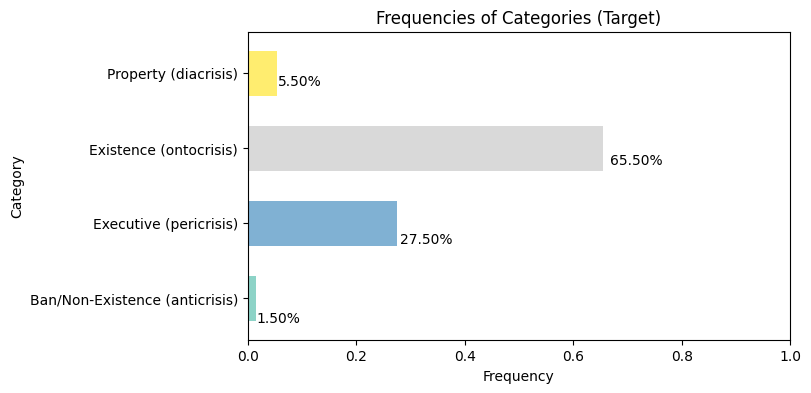

In [8]:
_ = utils.show_target_frequencies(df_gt['human']) #, encoding=encoding)

/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #270: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Ban/Non-Existence (anticrisis) 3
Executive (pericrisis) 55
Existence (ontocrisis) 131
Property (diacrisis) 11


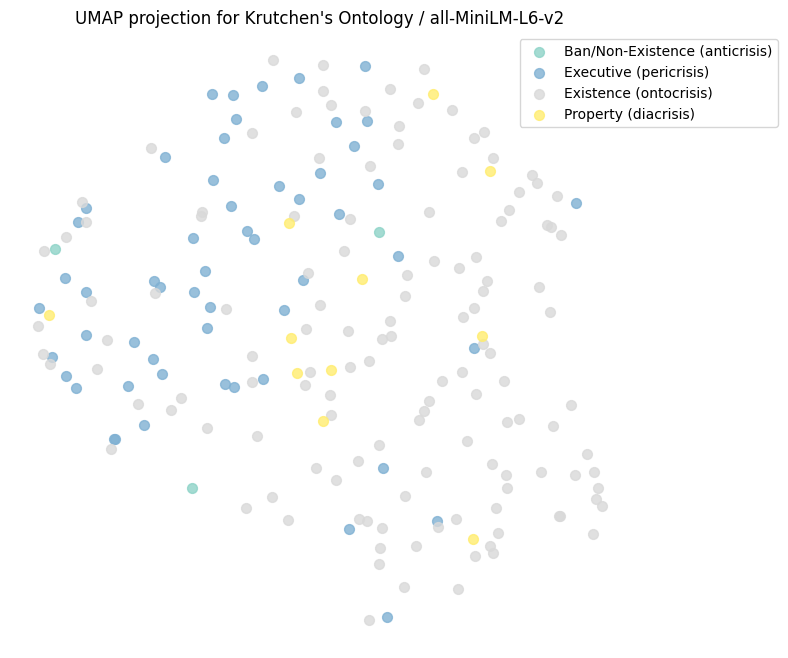

In [9]:
_ = utils.show_umap_projection(df_gt['human'], embeddings, title="UMAP projection for Krutchen's Ontology / "+DEFAULT_EMBEDDINGS, alpha=0.8)

In [10]:
X = embeddings_df.drop(columns=['target'])
y = embeddings_df['target']

In [11]:
# Preparation for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Assuming X_train, y_train are training data and labels
classes = np.unique(y_train) # encoding
weights = compute_class_weight(
    class_weight='balanced', 
    classes=classes, 
    y=y_train
)

class_weights_dict = dict(zip(classes, weights))
class_weights_dict

{0: 18.75, 1: 0.8928571428571429, 2: 0.3826530612244898, 3: 4.6875}

In [12]:
# Training the classifier 
classifier = CatBoostClassifier(iterations=250, loss_function='MultiClass', class_weights=class_weights_dict, verbose=False, random_seed=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [13]:
# Compute metrics
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [14]:
precision, recall, fscore, support = precision_recall_fscore_support(y_test, y_pred, average=None)

print("Metrics per class:")
print(f"  Precision: {precision}")
print(f"  Recall:    {recall}")
print(f"  F-measure: {fscore}")
print(f"  Support:   {support}\n")

# 3. Compute overall metrics using different averaging methods

# Macro average: calculates metrics for each label and finds their unweighted mean. 
# This does not take label imbalance into account.
macro_precision, macro_recall, macro_fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

print("Overall (Macro) Metrics:")
print(f"  Precision: {macro_precision:.4f}")
print(f"  Recall:    {macro_recall:.4f}")
print(f"  F-measure: {macro_fscore:.4f}\n")

# Weighted average: calculates metrics for each label and finds their average 
# weighted by support (the number of true instances for each label).
weighted_precision, weighted_recall, weighted_fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print("Overall (Weighted) Metrics:")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall:    {weighted_recall:.4f}")
print(f"  F-measure: {weighted_fscore:.4f}\n")

# Micro average: calculates metrics globally by counting the total true positives, 
# false negatives, and false positives. Useful for multi-label problems.
micro_precision, micro_recall, micro_fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')

print("Overall (Micro) Metrics:")
print(f"  Precision: {micro_precision:.4f}")
print(f"  Recall:    {micro_recall:.4f}")
print(f"  F-measure: {micro_fscore:.4f}")

# Note: Micro precision, recall, and f-measure are all equal to overall accuracy.
print(f"  Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Metrics per class:
  Precision: [0.         0.75       0.76190476 0.        ]
  Recall:    [0.         0.46153846 0.96969697 0.        ]
  F-measure: [0.         0.57142857 0.85333333 0.        ]
  Support:   [ 1 13 33  3]

Overall (Macro) Metrics:
  Precision: 0.3780
  Recall:    0.3578
  F-measure: 0.3562

Overall (Weighted) Metrics:
  Precision: 0.6979
  Recall:    0.7600
  F-measure: 0.7118

Overall (Micro) Metrics:
  Precision: 0.7600
  Recall:    0.7600
  F-measure: 0.7600
  Overall Accuracy: 0.7600


/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

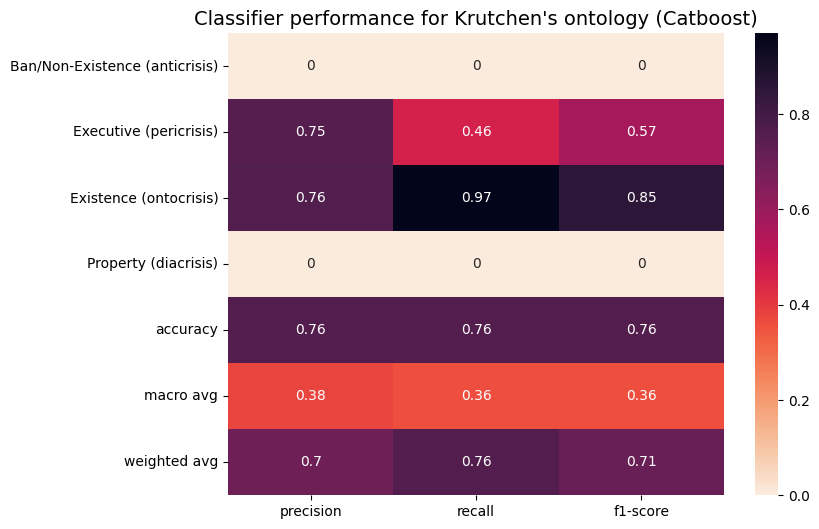

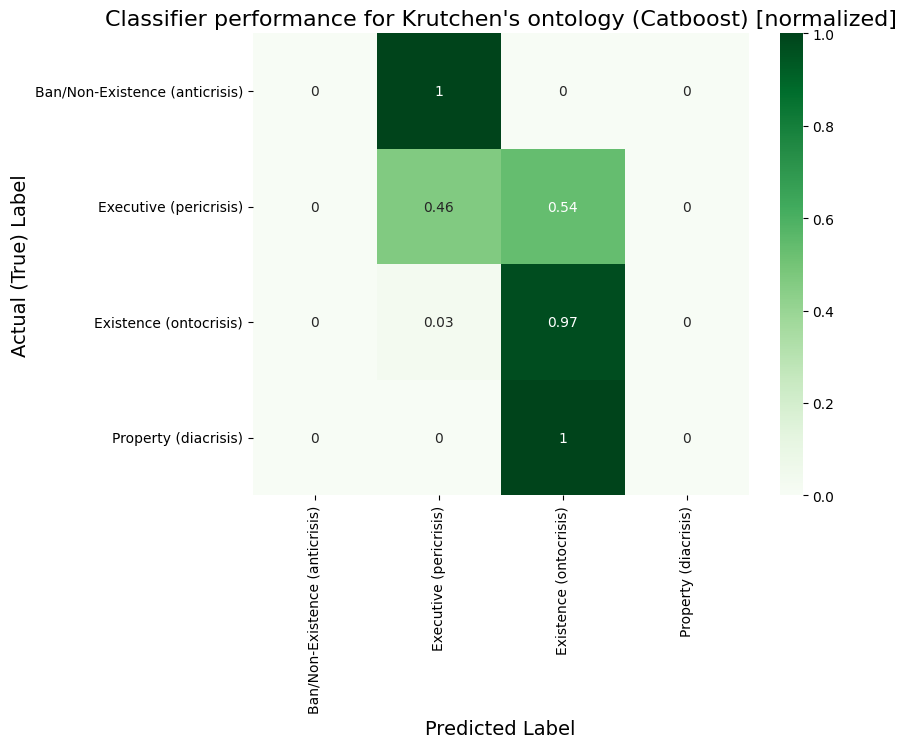

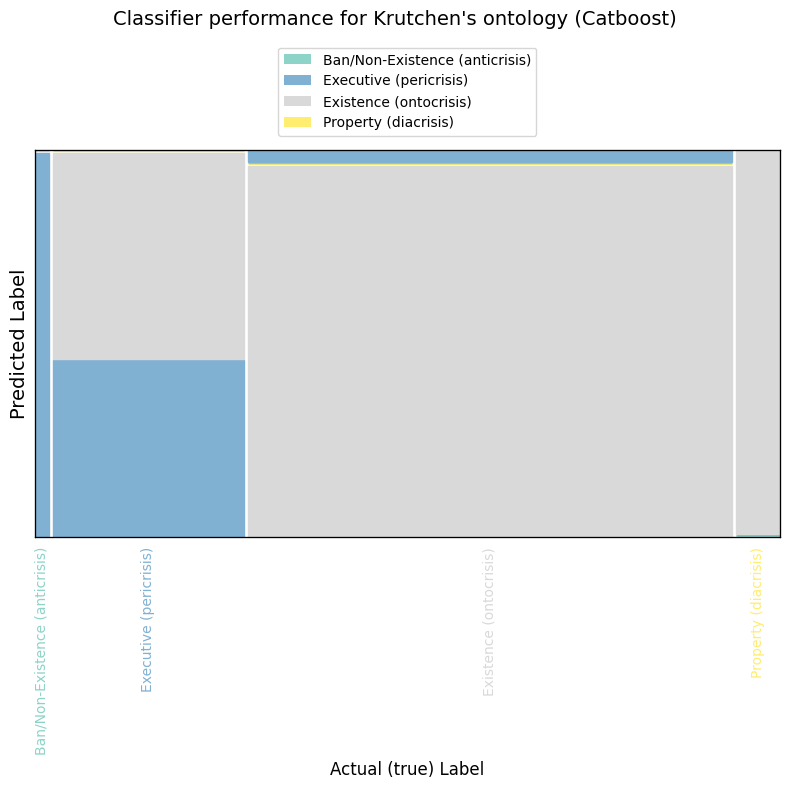

In [15]:
title = "Classifier performance for Krutchen's ontology (Catboost)"

utils.show_classification_report(report, title=title)
utils.show_confusion_matrix(cm_df, title=title, normalized=True)
_ = utils.show_classification_mosaic(cm, cm_labels=list(le.classes_), title=title, figsize=(8,8))

In [16]:
mcoeff = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Coefficient (test): {mcoeff:.2f}")

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa (test): {kappa:.2f}")

y_pred_all = classifier.predict(X)
kappa = cohen_kappa_score(y, y_pred_all)
print(f"Cohen's Kappa (all): {kappa:.2f}")

Matthews Coefficient (test): 0.45
Cohen's Kappa (test): 0.41
Cohen's Kappa (all): 0.87


---

### Quality Attributes for Design Decisions

In [17]:
labels = [str(member.value) for member in QualityAttributesEnum]
print(len(labels), labels)

11 ['Performance', 'Reliability', 'Security', 'Maintainability', 'Scalability', 'Usability', 'Portability', 'Compatibility', 'Observability', 'Testability', 'Other/Only Functional Concern']


In [18]:
# Load the ground truth dataset
relative_path = os.path.join('..', QAS_GROUND_TRUTH)
df_gt = pd.read_csv(relative_path, sep=';').dropna(subset=['text', 'human', 'ADR'])
print(df_gt.shape)
print(len(df_gt['human'].unique()), df_gt['human'].unique())
print(len(df_gt['primary_category'].unique()), df_gt['primary_category'].unique())

df_gt.head()

(200, 10)
11 ['Maintainability' 'Compatibility' 'Other/Only Functional Concern'
 'Performance' 'Security' 'Scalability' 'Observability' 'Usability'
 'Testability' 'Reliability' 'Portability']
11 ['Maintainability' 'Other/Only Functional Concern' 'Testability'
 'Performance' 'Security' 'Observability' 'Compatibility' 'Scalability'
 'Portability' 'Reliability' 'Usability']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,Human-old,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Maintainability,The ADR discusses implementing an architectura...,"0,75",Maintainability,Maintainability,1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Maintainability,The ADR discusses using Ansible roles and play...,"0,60",Compatibility,Compatibility,0.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Other/Only Functional Concern,The ADR primarily discusses versioning and rel...,"0,30",Other/Only Functional Concern,Other/Only Functional Concern,1.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Maintainability,The ADR primarily addresses how configuration ...,"0,75",Maintainability,Maintainability,1.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Testability,The ADR primarily discusses procedural and ope...,"0,20",Maintainability,Maintainability,0.0,# Cutting release branch does not create a set...


In [19]:
# Convert the column to a list of strings
sentences = df_gt['raw_text'].tolist()

# Generate embeddings (numpy array)

file = "./sample/raw_text_"+DEFAULT_EMBEDDINGS+".csv"
relative_path = os.path.join('..', file)
if not os.path.isfile(relative_path):
    print("Computing and saving embeddings ...", relative_path)
    embeddings = embeddings_model.embed_documents(sentences)
    embeddings_df = pd.DataFrame(embeddings)
    embeddings_df.to_csv(relative_path, index=False)
else:
    print("Loading embeddings ...", relative_path)
    embeddings_df = pd.read_csv(relative_path)
    embeddings = embeddings_df.values
print("Embeddings dimensions:", embeddings_df.shape)

# Encoding target
le = LabelEncoder()
encoding = le.fit_transform(labels)
target = le.transform(df_gt['human'].values)

embeddings_df['target'] = target
embeddings_df

Loading embeddings ... .././sample/raw_text_all-MiniLM-L6-v2.csv
Embeddings dimensions: (200, 384)


,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,target
0,-0.087746,-0.025783,-0.011399,0.072509,0.023523,0.051975,0.016978,0.024228,0.003429,-0.008411,...,0.028746,-0.044075,-0.022039,0.051252,-0.004270,0.029241,0.024829,0.050281,0.016047,1
1,-0.034718,0.029133,0.060015,-0.034530,-0.016033,-0.037277,-0.065005,-0.029227,-0.027280,0.048413,...,0.061427,-0.057165,0.070694,0.094382,0.003763,0.026396,0.020977,0.012519,-0.071028,0
2,-0.032316,0.073125,0.067982,-0.046770,0.035536,-0.036736,0.024030,-0.005913,0.002147,0.042534,...,0.082122,-0.048552,0.032370,0.082352,0.000186,0.061504,-0.017563,0.069962,0.031594,3
3,-0.080915,0.054267,-0.035858,0.024047,0.012388,-0.088769,0.019455,0.047597,-0.098465,-0.006181,...,0.046351,0.000392,0.071441,0.011201,-0.057204,0.024965,-0.032989,-0.056327,0.021423,1
4,-0.020906,-0.014489,0.032620,-0.034910,0.048718,-0.081320,-0.040000,0.035241,-0.041719,0.072459,...,0.070154,0.012068,-0.032626,0.067403,0.027646,-0.005853,-0.042328,0.095363,-0.048269,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-0.067137,-0.057264,-0.002712,-0.036436,-0.090109,-0.076199,-0.121965,-0.044534,-0.015054,0.020452,...,-0.028473,-0.032056,-0.012594,0.065213,0.063879,0.108941,-0.071546,-0.007906,-0.009648,8
196,-0.064192,0.010335,-0.043221,-0.027132,0.054785,-0.060619,-0.033178,-0.004337,-0.010425,-0.021680,...,0.071179,-0.040867,0.016918,0.087577,0.021079,0.115372,-0.030115,0.074096,-0.006207,5
197,-0.042593,0.014191,0.031190,0.015994,0.052952,-0.033803,0.017739,-0.023913,-0.034724,0.007231,...,-0.019793,0.029093,0.051192,0.091531,-0.031203,0.049976,-0.010754,0.086618,0.037443,3
198,-0.004285,0.019086,-0.004175,-0.023537,0.094394,-0.029927,0.014623,0.012204,-0.041464,0.008638,...,0.103210,-0.020175,-0.119202,0.100872,0.043522,-0.016107,-0.019503,-0.022933,0.001127,1


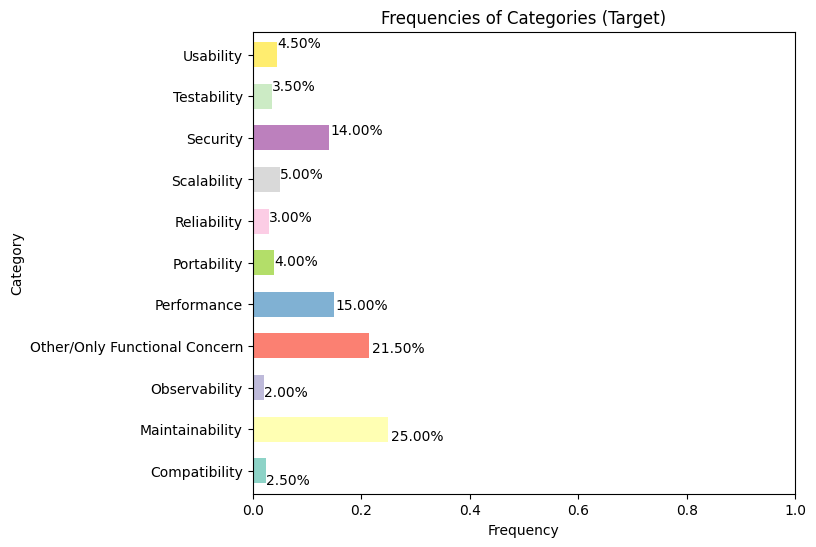

In [20]:
_ = utils.show_target_frequencies(df_gt['human'], figsize=(7,6)) #, encoding=encoding)

/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Compatibility 5
Maintainability 50
Observability 4
Other/Only Functional Concern 43
Performance 30
Portability 8
Reliability 6
Scalability 10
Security 28
Testability 7
Usability 9


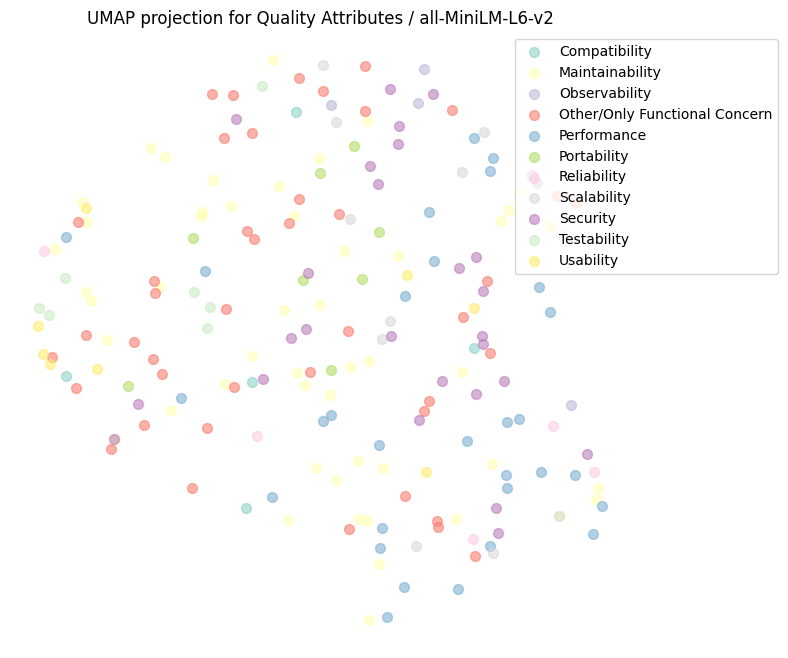

In [21]:
_ = utils.show_umap_projection(df_gt['human'], embeddings, title="UMAP projection for Quality Attributes / "+DEFAULT_EMBEDDINGS)

In [22]:
X = embeddings_df.drop(columns=['target'])
y = embeddings_df['target']

In [23]:
# Preparation for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Assuming X_train, y_train are training data and labels
classes = np.unique(y_train) # encoding
weights = compute_class_weight(
    class_weight='balanced', 
    classes=classes, 
    y=y_train
)

class_weights_dict = dict(zip(classes, weights))
class_weights_dict

{0: 3.409090909090909,
 1: 0.36855036855036855,
 2: 4.545454545454546,
 3: 0.42613636363636365,
 4: 0.5928853754940712,
 5: 2.272727272727273,
 6: 2.727272727272727,
 7: 1.948051948051948,
 8: 0.6493506493506493,
 9: 2.727272727272727,
 10: 1.948051948051948}

In [24]:
# Training the classifier 
classifier = CatBoostClassifier(iterations=250, loss_function='MultiClass', class_weights=class_weights_dict, verbose=False, random_seed=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [25]:
# Compute metrics
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [26]:
precision, recall, fscore, support = precision_recall_fscore_support(y_test, y_pred, average=None)

print("Metrics per class:")
print(f"  Precision: {precision}")
print(f"  Recall:    {recall}")
print(f"  F-measure: {fscore}")
print(f"  Support:   {support}\n")

# 3. Compute overall metrics using different averaging methods

# Macro average: calculates metrics for each label and finds their unweighted mean. 
# This does not take label imbalance into account.
macro_precision, macro_recall, macro_fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

print("Overall (Macro) Metrics:")
print(f"  Precision: {macro_precision:.4f}")
print(f"  Recall:    {macro_recall:.4f}")
print(f"  F-measure: {macro_fscore:.4f}\n")

# Weighted average: calculates metrics for each label and finds their average 
# weighted by support (the number of true instances for each label).
weighted_precision, weighted_recall, weighted_fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print("Overall (Weighted) Metrics:")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall:    {weighted_recall:.4f}")
print(f"  F-measure: {weighted_fscore:.4f}\n")

# Micro average: calculates metrics globally by counting the total true positives, 
# false negatives, and false positives. Useful for multi-label problems.
micro_precision, micro_recall, micro_fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')

print("Overall (Micro) Metrics:")
print(f"  Precision: {micro_precision:.4f}")
print(f"  Recall:    {micro_recall:.4f}")
print(f"  F-measure: {micro_fscore:.4f}")

# Note: Micro precision, recall, and f-measure are all equal to overall accuracy.
print(f"  Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Metrics per class:
  Precision: [0.         0.28571429 0.         0.22222222 0.2        0.
 0.         0.         0.21428571 0.         0.        ]
  Recall:    [0.         0.46153846 0.         0.18181818 0.14285714 0.
 0.         0.         0.42857143 0.         0.        ]
  F-measure: [0.         0.35294118 0.         0.2        0.16666667 0.
 0.         0.         0.28571429 0.         0.        ]
  Support:   [ 1 13  1 11  7  2  1  3  7  2  2]

Overall (Macro) Metrics:
  Precision: 0.0838
  Recall:    0.1104
  F-measure: 0.0914

Overall (Weighted) Metrics:
  Precision: 0.1812
  Recall:    0.2400
  F-measure: 0.1991

Overall (Micro) Metrics:
  Precision: 0.2400
  Recall:    0.2400
  F-measure: 0.2400
  Overall Accuracy: 0.2400


/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

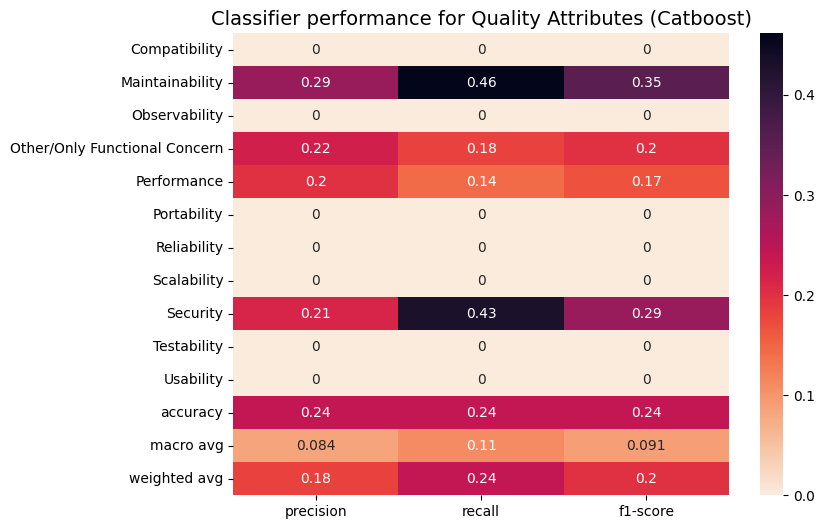

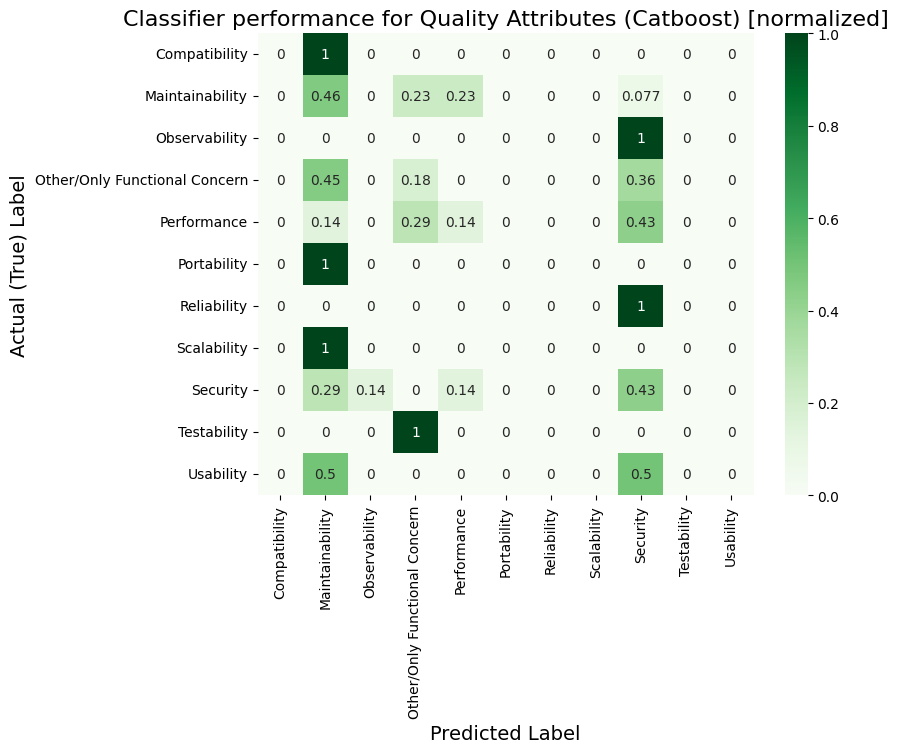

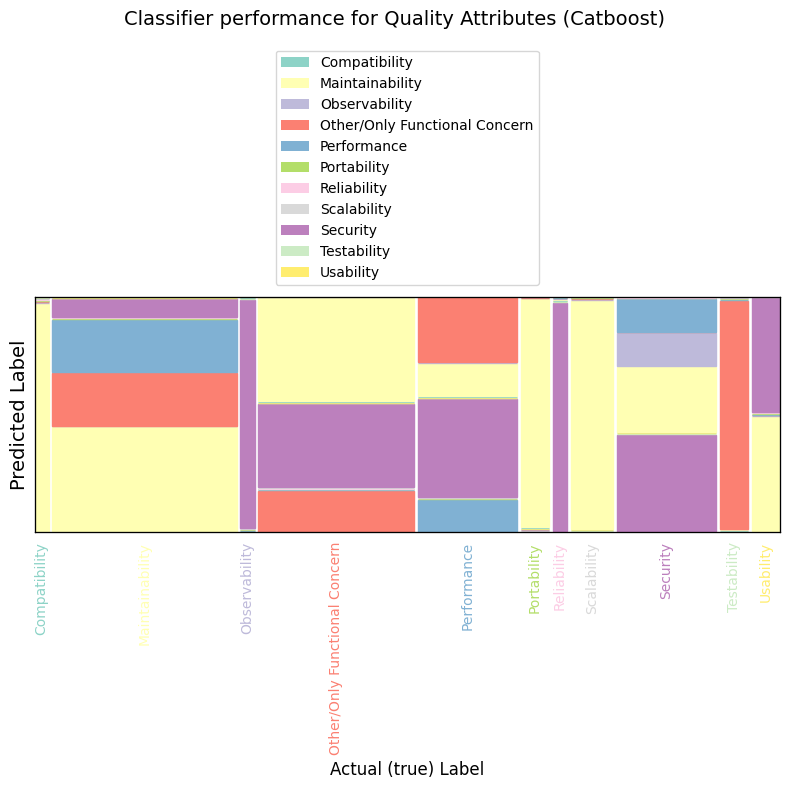

In [27]:
title = "Classifier performance for Quality Attributes (Catboost)"

utils.show_classification_report(report, title=title)
utils.show_confusion_matrix(cm_df, title=title, normalized=True)
_ = utils.show_classification_mosaic(cm, cm_labels=list(le.classes_), title=title, figsize=(8,8))

In [28]:
mcoeff = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Coefficient (test): {mcoeff:.2f}")

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa (test): {kappa:.2f}")

y_pred_all = classifier.predict(X)
kappa = cohen_kappa_score(y, y_pred_all)
print(f"Cohen's Kappa (all): {kappa:.2f}")

Matthews Coefficient (test): 0.05
Cohen's Kappa (test): 0.05
Cohen's Kappa (all): 0.77


---

### Zimmermann's Categories for Design Decisions

In [29]:
labels = [str(member.value) for member in ZimmermannEnum]
print(len(labels), labels)


9 ['Design', 'Technology', 'Infrastructure', 'Organizational/Process', 'Constraint', 'Quality Attribute', 'Crosscutting Concerns', 'Implementation', 'Other']


In [30]:
# Load the ground truth dataset
relative_path = os.path.join('..', ZIMMERMANN_GROUND_TRUTH)
df_gt = pd.read_csv(relative_path, sep=';').dropna(subset=['text', 'human', 'ADR'])
print(df_gt.shape)
print(len(df_gt['human'].unique()), df_gt['human'].unique())
print(len(df_gt['primary_category'].unique()), df_gt['primary_category'].unique())

df_gt.head()
# Note: 'Quality Attribute' is missing in the sampled ground truth!

(200, 9)
8 ['Design' 'Infrastructure' 'Technology' 'Implementation'
 'Crosscutting Concerns' 'Constraint' 'Organizational/Process' 'Other']
8 ['Design' 'Infrastructure' 'Technology' 'Constraint' 'Other'
 'Crosscutting Concerns' 'Implementation' 'Organizational/Process']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Design,The ADR primarily discusses the architectural ...,"0,85",Design,1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Infrastructure,The ADR focuses on provisioning and deployment...,"0,70",Infrastructure,1.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Technology,The ADR focuses on establishing a versioning a...,"0,75",Technology,1.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Design,The ADR primarily addresses the organization a...,"0,85",Infrastructure,0.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Technology,The ADR primarily discusses changes to the rel...,"0,60",Technology,1.0,# Cutting release branch does not create a set...


In [31]:
# Convert the column to a list of strings
sentences = df_gt['raw_text'].tolist()

# Generate embeddings (numpy array)

file = "./sample/raw_text_"+DEFAULT_EMBEDDINGS+".csv"
relative_path = os.path.join('..', file)
if not os.path.isfile(relative_path):
    print("Computing and saving embeddings ...", relative_path)
    embeddings = embeddings_model.embed_documents(sentences)
    embeddings_df = pd.DataFrame(embeddings)
    embeddings_df.to_csv(relative_path, index=False)
else:
    print("Loading embeddings ...", relative_path)
    embeddings_df = pd.read_csv(relative_path)
    embeddings = embeddings_df.values
print("Embeddings dimensions:", embeddings_df.shape)

# Encoding target
le = LabelEncoder()
encoding = le.fit_transform(labels)
target = le.transform(df_gt['human'].values)

embeddings_df['target'] = target
embeddings_df

Loading embeddings ... .././sample/raw_text_all-MiniLM-L6-v2.csv
Embeddings dimensions: (200, 384)


,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,target
0,-0.087746,-0.025783,-0.011399,0.072509,0.023523,0.051975,0.016978,0.024228,0.003429,-0.008411,...,0.028746,-0.044075,-0.022039,0.051252,-0.004270,0.029241,0.024829,0.050281,0.016047,2
1,-0.034718,0.029133,0.060015,-0.034530,-0.016033,-0.037277,-0.065005,-0.029227,-0.027280,0.048413,...,0.061427,-0.057165,0.070694,0.094382,0.003763,0.026396,0.020977,0.012519,-0.071028,4
2,-0.032316,0.073125,0.067982,-0.046770,0.035536,-0.036736,0.024030,-0.005913,0.002147,0.042534,...,0.082122,-0.048552,0.032370,0.082352,0.000186,0.061504,-0.017563,0.069962,0.031594,8
3,-0.080915,0.054267,-0.035858,0.024047,0.012388,-0.088769,0.019455,0.047597,-0.098465,-0.006181,...,0.046351,0.000392,0.071441,0.011201,-0.057204,0.024965,-0.032989,-0.056327,0.021423,4
4,-0.020906,-0.014489,0.032620,-0.034910,0.048718,-0.081320,-0.040000,0.035241,-0.041719,0.072459,...,0.070154,0.012068,-0.032626,0.067403,0.027646,-0.005853,-0.042328,0.095363,-0.048269,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-0.067137,-0.057264,-0.002712,-0.036436,-0.090109,-0.076199,-0.121965,-0.044534,-0.015054,0.020452,...,-0.028473,-0.032056,-0.012594,0.065213,0.063879,0.108941,-0.071546,-0.007906,-0.009648,2
196,-0.064192,0.010335,-0.043221,-0.027132,0.054785,-0.060619,-0.033178,-0.004337,-0.010425,-0.021680,...,0.071179,-0.040867,0.016918,0.087577,0.021079,0.115372,-0.030115,0.074096,-0.006207,8
197,-0.042593,0.014191,0.031190,0.015994,0.052952,-0.033803,0.017739,-0.023913,-0.034724,0.007231,...,-0.019793,0.029093,0.051192,0.091531,-0.031203,0.049976,-0.010754,0.086618,0.037443,2
198,-0.004285,0.019086,-0.004175,-0.023537,0.094394,-0.029927,0.014623,0.012204,-0.041464,0.008638,...,0.103210,-0.020175,-0.119202,0.100872,0.043522,-0.016107,-0.019503,-0.022933,0.001127,2


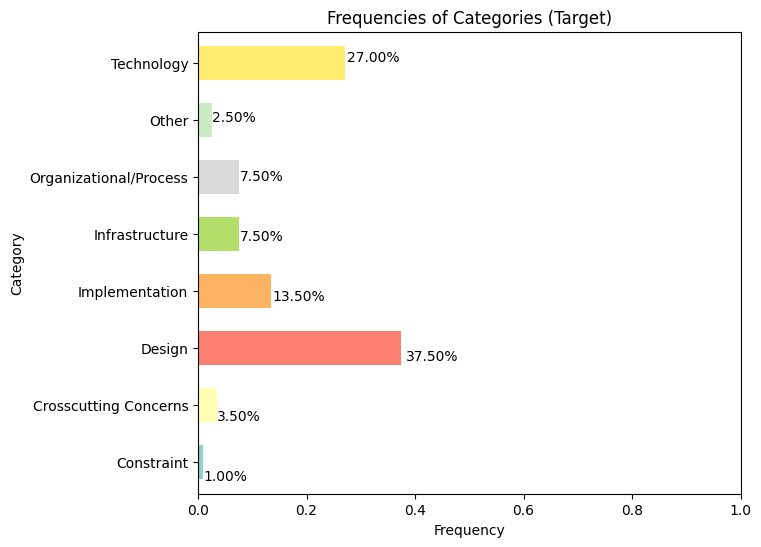

In [32]:
my_colors = utils.show_target_frequencies(df_gt['human'], figsize=(7,6)) #, encoding=encoding)

In [33]:
my_colors

{'Constraint': '#8dd3c7',
 'Crosscutting Concerns': '#ffffb3',
 'Design': '#fb8072',
 'Implementation': '#fdb462',
 'Infrastructure': '#b3de69',
 'Organizational/Process': '#d9d9d9',
 'Other': '#ccebc5',
 'Technology': '#ffed6f'}

/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Constraint 2
Crosscutting Concerns 7
Design 75
Implementation 27
Infrastructure 15
Organizational/Process 15
Other 5
Technology 54


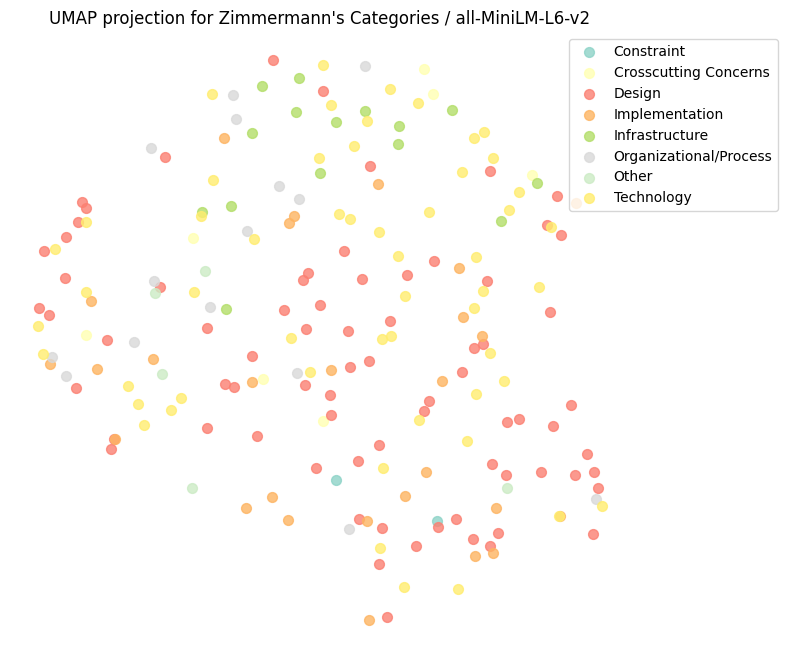

In [34]:
_ = utils.show_umap_projection(df_gt['human'], embeddings, color_dict=my_colors, alpha=0.8, title="UMAP projection for Zimmermann's Categories / "+DEFAULT_EMBEDDINGS)

In [35]:
X = embeddings_df.drop(columns=['target'])
y = embeddings_df['target']

In [36]:
# Preparation for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Assuming X_train, y_train are training data and labels
classes = np.unique(y_train) # encoding
weights = compute_class_weight(
    class_weight='balanced', 
    classes=classes, 
    y=y_train
)

class_weights_dict = dict(zip(classes, weights))
class_weights_dict

{0: 9.375,
 1: 3.75,
 2: 0.33482142857142855,
 3: 0.9375,
 4: 1.7045454545454546,
 5: 1.7045454545454546,
 6: 4.6875,
 8: 0.4573170731707317}

In [37]:
# Training the classifier 
classifier = CatBoostClassifier(iterations=250, loss_function='MultiClass', class_weights=class_weights_dict, verbose=False, random_seed=42)
classifier.fit(X_train, y_train) # It takes a while (5min) with 250 iterations (maybe try with a small number of iterations?)

y_pred = classifier.predict(X_test)

In [38]:
print("All labels:", le.classes_)
unique_test_labels = list(set(y_test)) #y_test.unique()
print("Labels in test set:", unique_test_labels)
actual_classes = list(le.inverse_transform(unique_test_labels))
actual_classes


All labels: ['Constraint' 'Crosscutting Concerns' 'Design' 'Implementation'
 'Infrastructure' 'Organizational/Process' 'Other' 'Quality Attribute'
 'Technology']
Labels in test set: [1, 2, 3, 4, 5, 6, 8]


['Crosscutting Concerns',
 'Design',
 'Implementation',
 'Infrastructure',
 'Organizational/Process',
 'Other',
 'Technology']

In [39]:
# Compute metrics
report = classification_report(y_test, y_pred, labels=unique_test_labels, target_names=actual_classes, output_dict=True)
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=actual_classes, columns=actual_classes)

/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [40]:
precision, recall, fscore, support = precision_recall_fscore_support(y_test, y_pred, average=None)

print("Metrics per class:")
print(f"  Precision: {precision}")
print(f"  Recall:    {recall}")
print(f"  F-measure: {fscore}")
print(f"  Support:   {support}\n")

# 3. Compute overall metrics using different averaging methods

# Macro average: calculates metrics for each label and finds their unweighted mean. 
# This does not take label imbalance into account.
macro_precision, macro_recall, macro_fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

print("Overall (Macro) Metrics:")
print(f"  Precision: {macro_precision:.4f}")
print(f"  Recall:    {macro_recall:.4f}")
print(f"  F-measure: {macro_fscore:.4f}\n")

# Weighted average: calculates metrics for each label and finds their average 
# weighted by support (the number of true instances for each label).
weighted_precision, weighted_recall, weighted_fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print("Overall (Weighted) Metrics:")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall:    {weighted_recall:.4f}")
print(f"  F-measure: {weighted_fscore:.4f}\n")

# Micro average: calculates metrics globally by counting the total true positives, 
# false negatives, and false positives. Useful for multi-label problems.
micro_precision, micro_recall, micro_fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')

print("Overall (Micro) Metrics:")
print(f"  Precision: {micro_precision:.4f}")
print(f"  Recall:    {micro_recall:.4f}")
print(f"  F-measure: {micro_fscore:.4f}")

# Note: Micro precision, recall, and f-measure are all equal to overall accuracy.
print(f"  Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Metrics per class:
  Precision: [0.         0.34482759 0.         1.         0.         0.
 0.16666667]
  Recall:    [0.         0.52631579 0.         0.25       0.         0.
 0.23076923]
  F-measure: [0.         0.41666667 0.         0.4        0.         0.
 0.19354839]
  Support:   [ 2 19  7  4  4  1 13]

Overall (Macro) Metrics:
  Precision: 0.2159
  Recall:    0.1439
  F-measure: 0.1443

Overall (Weighted) Metrics:
  Precision: 0.2544
  Recall:    0.2800
  F-measure: 0.2407

Overall (Micro) Metrics:
  Precision: 0.2800
  Recall:    0.2800
  F-measure: 0.2800
  Overall Accuracy: 0.2800


/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

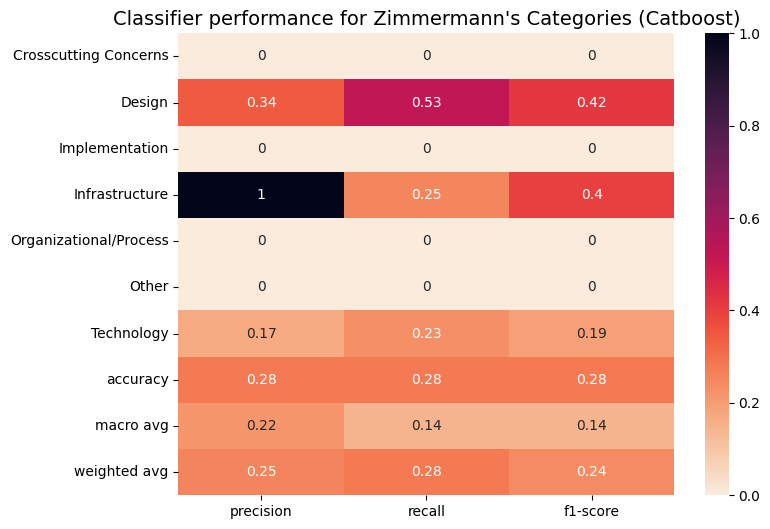

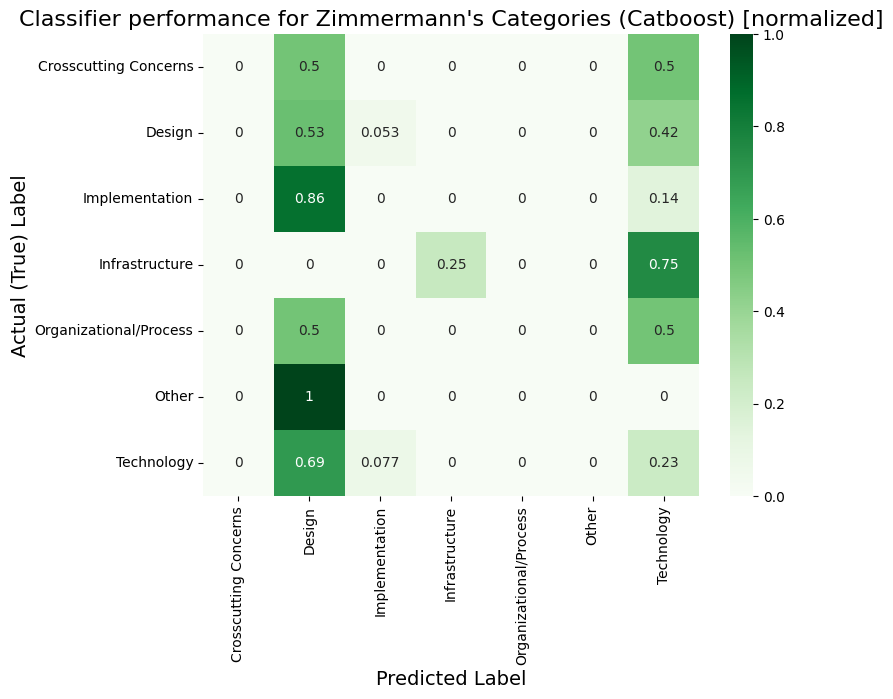

In [41]:
title = "Classifier performance for Zimmermann's Categories (Catboost)"

utils.show_classification_report(report, title=title)
utils.show_confusion_matrix(cm_df, title=title, normalized=True)

In [42]:
my_colors

{'Constraint': '#8dd3c7',
 'Crosscutting Concerns': '#ffffb3',
 'Design': '#fb8072',
 'Implementation': '#fdb462',
 'Infrastructure': '#b3de69',
 'Organizational/Process': '#d9d9d9',
 'Other': '#ccebc5',
 'Technology': '#ffed6f'}

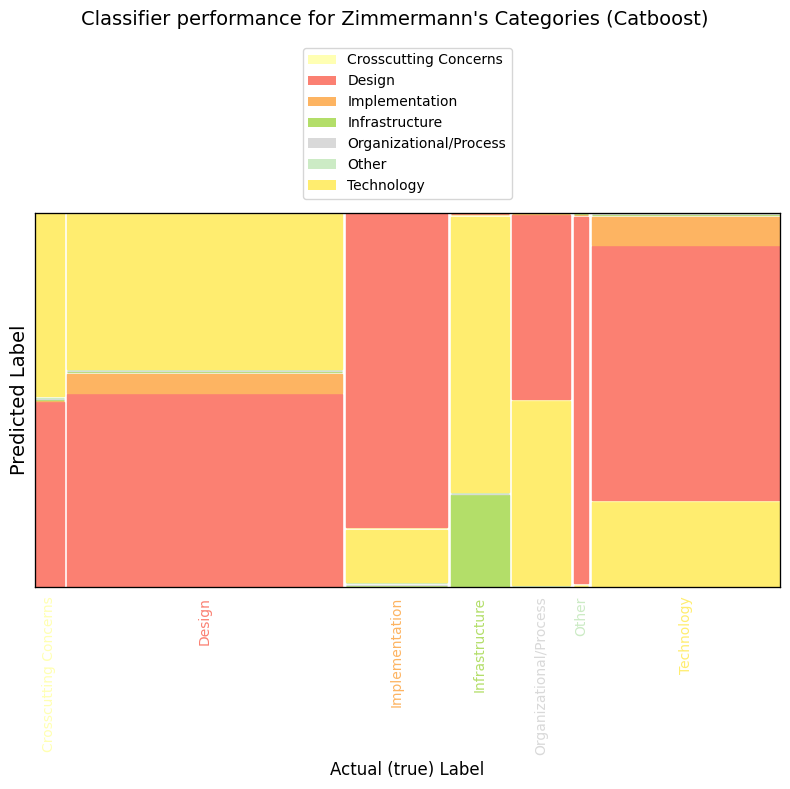

In [43]:
_ = utils.show_classification_mosaic(cm, cm_labels=actual_classes, color_dict=my_colors, title=title, figsize=(8,8))

In [44]:
actual_classes

['Crosscutting Concerns',
 'Design',
 'Implementation',
 'Infrastructure',
 'Organizational/Process',
 'Other',
 'Technology']

In [45]:
mcoeff = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Coefficient (test): {mcoeff:.2f}")

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa (test): {kappa:.2f}")

y_pred_all = classifier.predict(X)
kappa = cohen_kappa_score(y, y_pred_all)
print(f"Cohen's Kappa (all): {kappa:.2f}")

Matthews Coefficient (test): -0.07
Cohen's Kappa (test): -0.06
Cohen's Kappa (all): 0.76


---